# Laboratorio 5.1: Regresión con PyTorch (ATP Tennis)

**Dataset:** ATP matches hasta 2022  
**Tarea:** Predecir la duración del partido (`minutes`) a partir de características del partido.  
**Tipo de problema:** Regresión  


---
## Fase 1: Carga y Exploración del Dataset

El dataset tiene 188 161 partidos ATP con 49 columnas.  
Predecimos `minutes` (duración) a partir de: `surface`, `best_of`, `winner_rank`, `loser_rank`, `w_ace`, `l_ace`.

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
import os
%matplotlib inline

df = pd.read_csv('../Datasets/1_ATP_matches_D/atp_matches_till_2022.csv')
print(f"Filas × Columnas: {df.shape}")
df[['surface','best_of','winner_rank','loser_rank','w_ace','l_ace','minutes']].describe()


Filas × Columnas: (188161, 49)


,best_of,winner_rank,loser_rank,w_ace,l_ace,minutes
count,188161.000000,153197.000000,144834.000000,92220.000000,92219.000000,89511.000000
mean,3.441218,75.255716,112.884150,6.517708,4.828745,103.497403
std,0.830009,121.053512,162.191701,5.341289,4.670710,39.365772
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,3.000000,17.000000,37.000000,3.000000,2.000000,75.000000
50%,3.000000,44.000000,70.000000,5.000000,4.000000,96.000000
75%,3.000000,86.000000,118.000000,9.000000,7.000000,125.000000
max,5.000000,2101.000000,2159.000000,113.000000,103.000000,1146.000000


### 1.1 Distribución del target (`minutes`)

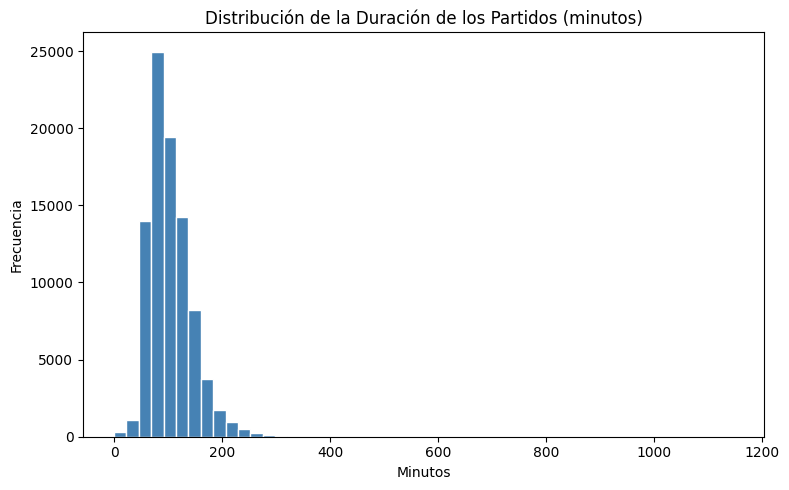

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

# Graficamos el histograma en ese único eje
df['minutes'].dropna().plot.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')

# Configuramos el título y las etiquetas para mayor claridad
ax.set_title('Distribución de la Duración de los Partidos (minutos)')
ax.set_xlabel('Minutos')
ax.set_ylabel('Frecuencia') # Es buena práctica añadir la etiqueta del eje Y

plt.tight_layout() # Ajusta el layout para que no se solapen los elementos
plt.show()



---
## Fase 2: Preprocesamiento

Usamos más variables, incluyendo ranking, edad, altura, estadísticas de servicio y contexto del torneo. Luego codificamos variables categóricas, eliminamos `NaN` y separamos en train (70%), val (15%), test (15%).

In [3]:
RAW_FEATURES = [
    'surface', 'best_of', 'draw_size', 'tourney_level', 'round',
    'winner_rank', 'loser_rank', 'winner_rank_points', 'loser_rank_points',
    'winner_age', 'loser_age', 'winner_ht', 'loser_ht',
    'w_ace', 'l_ace', 'w_df', 'l_df',
    'w_svpt', 'l_svpt', 'w_1stIn', 'l_1stIn',
    'w_1stWon', 'l_1stWon', 'w_2ndWon', 'l_2ndWon',
    'w_SvGms', 'l_SvGms', 'w_bpSaved', 'l_bpSaved', 'w_bpFaced', 'l_bpFaced'
]
TARGET = 'minutes'

df_clean = df[RAW_FEATURES + [TARGET]].copy()

# Usamos variables categóricas reales del dataset (sin ingeniería adicional)
categorical_cols = ['surface', 'tourney_level', 'round']
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, dtype=np.float32)

df_clean = df_clean.dropna()
FEATURES = [c for c in df_clean.columns if c != TARGET]

print(f"Filas tras limpiar NaN: {len(df_clean):,}")
print(f"Cantidad de features usadas: {len(FEATURES)}")

X = df_clean[FEATURES].values.astype(np.float32)
y = df_clean[TARGET].values.astype(np.float32).reshape(-1, 1)

# Split 70/15/15
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
n_train = int(0.70 * len(X))
n_val   = int(0.15 * len(X))

idx_tr  = idx[:n_train]
idx_val = idx[n_train:n_train + n_val]
idx_te  = idx[n_train + n_val:]

X_tr, y_tr   = X[idx_tr],  y[idx_tr]
X_val, y_val = X[idx_val], y[idx_val]
X_te, y_te   = X[idx_te],  y[idx_te]

# Normalizar features con estadísticas del train
mean_X = X_tr.mean(axis=0); std_X = X_tr.std(axis=0) + 1e-8
mean_y = y_tr.mean();        std_y = y_tr.std()  + 1e-8

X_tr  = (X_tr  - mean_X) / std_X
X_val = (X_val - mean_X) / std_X
X_te  = (X_te  - mean_X) / std_X

y_tr  = (y_tr  - mean_y) / std_y
y_val = (y_val - mean_y) / std_y
y_te  = (y_te  - mean_y) / std_y

print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}")


Filas tras limpiar NaN: 86,751
Cantidad de features usadas: 47
Train: (60725, 47) | Val: (13012, 47) | Test: (13014, 47)


---
## Fase 3: Dataset y DataLoader

In [4]:
class ATPDataset(Dataset):
    """Dataset para ATP: normalización ya aplicada externamente."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 512
train_ds = ATPDataset(X_tr,  y_tr)
val_ds   = ATPDataset(X_val, y_val)
test_ds  = ATPDataset(X_te,  y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape} | Batch y: {yb.shape}")


Batch X: torch.Size([512, 47]) | Batch y: torch.Size([512, 1])


---
## Fase 4: Modelo — MLP Regresión

Para regresión la capa de salida tiene **1 neurona sin activación** y la función de pérdida es `MSELoss`.

In [5]:
class MLPReg(nn.Module):
    """MLP para regresión con BatchNorm y Dropout."""
    def __init__(self, in_features=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),          nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),           nn.ReLU(),
            nn.Linear(32, 1)             # sin activación → regresión
        )

    def forward(self, x): return self.net(x)

modelo = MLPReg(in_features=len(FEATURES))
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")
print(modelo)


Parámetros entrenables: 16,897
MLPReg(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Fase 4.1: Entrenamiento

In [6]:
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS      = 50
LR          = 1e-3
FEATURE_TAG = f'f{len(FEATURES)}'
BEST_PATH   = f'./checkpoints/atp_best_{FEATURE_TAG}.pth'
RESUME_PATH = f'./checkpoints/atp_resume_{FEATURE_TAG}.pth'
os.makedirs('./checkpoints', exist_ok=True)

modelo = MLPReg(in_features=len(FEATURES)).to(DEVICE)
optimizer = torch.optim.Adam(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
criterion = nn.MSELoss()

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

# ── Reanudar si existe backup (compatible con arquitectura actual) ──
if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, weights_only=False)
    try:
        modelo.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch   = ckpt['epoch'] + 1
        best_val_loss = ckpt['best_val_loss']
        history       = ckpt['history']
        print(f"▶ Reanudando desde época {start_epoch} ({FEATURE_TAG})")
    except RuntimeError as e:
        start_epoch = 1
        print('⚠️ Checkpoint incompatible con la arquitectura actual. Entrenamiento desde cero.')
        print(f'   Detalle: {e}')
else:
    start_epoch = 1
    print(f"▶ Entrenamiento desde cero ({FEATURE_TAG}).")

for epoch in range(start_epoch, EPOCHS + 1):
    # Entrenamiento
    modelo.train()
    t_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(modelo(xb), yb)
        loss.backward(); optimizer.step()
        t_loss += loss.item() * xb.size(0)
    scheduler.step()

    # Validación
    modelo.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(modelo(xb), yb).item() * xb.size(0)

    tl = t_loss / len(train_ds)
    vl = v_loss / len(val_ds)
    history['train_loss'].append(tl); history['val_loss'].append(vl)

    # Best model
    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(modelo.state_dict(), BEST_PATH)
        print(f"   ✓ Mejor modelo guardado (val_loss={vl:.4f})")

    # Backup cada 10 épocas
    if epoch % 10 == 0:
        torch.save({'epoch': epoch, 'model_state': modelo.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'scheduler_state': scheduler.state_dict(),
                    'history': history, 'best_val_loss': best_val_loss}, RESUME_PATH)
        print(f"   💾 Backup (época {epoch}/{EPOCHS})")

    print(f"Epoch {epoch:3d}/{EPOCHS} | train_loss={tl:.4f} | val_loss={vl:.4f}")

modelo.load_state_dict(torch.load(BEST_PATH, weights_only=True))
print(f"\n✅ Entrenamiento finalizado. Mejor val_loss: {best_val_loss:.4f}")


▶ Entrenamiento desde cero (f47).
   ✓ Mejor modelo guardado (val_loss=0.1138)
Epoch   1/50 | train_loss=0.2162 | val_loss=0.1138
   ✓ Mejor modelo guardado (val_loss=0.1084)
Epoch   2/50 | train_loss=0.1508 | val_loss=0.1084
Epoch   3/50 | train_loss=0.1465 | val_loss=0.1098
Epoch   4/50 | train_loss=0.1424 | val_loss=0.1111
   ✓ Mejor modelo guardado (val_loss=0.1071)
Epoch   5/50 | train_loss=0.1436 | val_loss=0.1071
Epoch   6/50 | train_loss=0.1408 | val_loss=0.1142
   ✓ Mejor modelo guardado (val_loss=0.1043)
Epoch   7/50 | train_loss=0.1383 | val_loss=0.1043
Epoch   8/50 | train_loss=0.1379 | val_loss=0.1066
Epoch   9/50 | train_loss=0.1372 | val_loss=0.1112
   ✓ Mejor modelo guardado (val_loss=0.1038)
   💾 Backup (época 10/50)
Epoch  10/50 | train_loss=0.1358 | val_loss=0.1038
Epoch  11/50 | train_loss=0.1366 | val_loss=0.1128
Epoch  12/50 | train_loss=0.1347 | val_loss=0.1041
Epoch  13/50 | train_loss=0.1343 | val_loss=0.1039
Epoch  14/50 | train_loss=0.1340 | val_loss=0.1042
E

## Fase 4.2: Curvas de entrenamiento

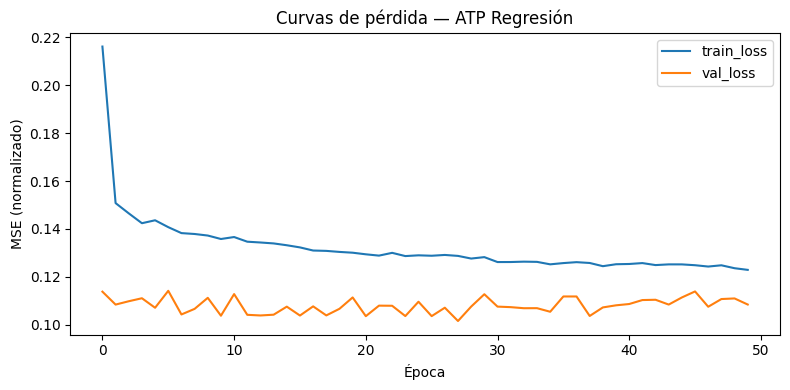

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'],   label='val_loss')
plt.xlabel('Época'); plt.ylabel('MSE (normalizado)')
plt.title('Curvas de pérdida — ATP Regresión')
plt.legend(); plt.tight_layout(); plt.show()


---
## Fase 5: Guardar / Cargar Modelos

### 5.1 `state_dict` (recomendado)

In [8]:
torch.save(modelo.state_dict(), './checkpoints/atp_demo.pth')

model_cargado = MLPReg(in_features=len(FEATURES))
model_cargado.load_state_dict(torch.load('./checkpoints/atp_demo.pth', weights_only=True))
model_cargado.eval()
print("state_dict cargado correctamente ✓")


state_dict cargado correctamente ✓


### 5.2 Modelo completo

In [9]:
torch.save(modelo, './checkpoints/atp_completo.pt')
model_full = torch.load('./checkpoints/atp_completo.pt', weights_only=False)
model_full.eval()
print("Modelo completo cargado ✓")


Modelo completo cargado ✓


### 5.3 TorchScript

In [10]:
modelo.cpu().eval()
scripted = torch.jit.script(modelo)
scripted.save('./checkpoints/atp_scripted.pt')
loaded_ts = torch.jit.load('./checkpoints/atp_scripted.pt')
demo_in   = torch.randn(1, len(FEATURES))
print("TorchScript ✓ | output shape:", loaded_ts(demo_in).shape)
modelo.to(DEVICE)


TorchScript ✓ | output shape: torch.Size([1, 1])


MLPReg(
  (net): Sequential(
    (0): Linear(in_features=47, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

---
## Fase 6: Evaluación Final en Test

### 6.1 Predicciones en escala original

In [11]:
best_model = MLPReg(in_features=len(FEATURES))
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.eval()
best_model.to(DEVICE)

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = best_model(xb).cpu().numpy()
        all_preds.append(pred)
        all_true.append(yb.numpy())

preds_norm = np.concatenate(all_preds)
trues_norm = np.concatenate(all_true)

# Deshacer normalización del target
preds_min = preds_norm * std_y + mean_y
trues_min = trues_norm * std_y + mean_y

print('Predicciones en escala original listas ✓')


Predicciones en escala original listas ✓


### 6.2 Curva de accuracy por tolerancia (regresión)

En regresión no se usa accuracy clásica de clasificación.  
Acá medimos el porcentaje de predicciones que caen dentro de ±k minutos del valor real.

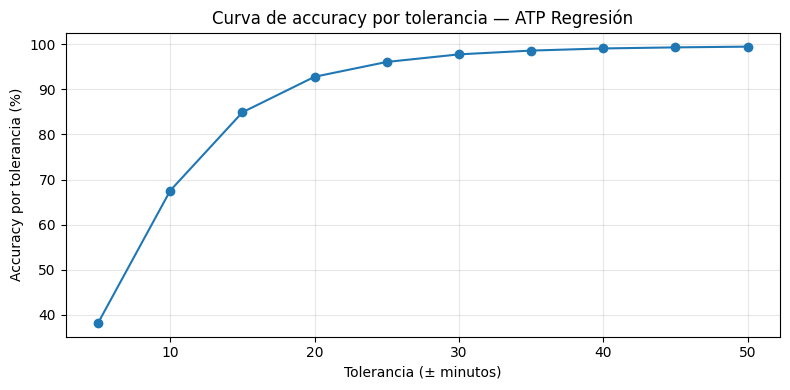

Accuracy ±10 min: 67.56%
Accuracy ±15 min: 84.93%
Accuracy ±20 min: 92.82%


In [12]:
abs_err = np.abs(preds_min - trues_min).reshape(-1)
tol_values = np.arange(5, 55, 5)
tol_acc = np.array([(abs_err <= t).mean() for t in tol_values])

plt.figure(figsize=(8, 4))
plt.plot(tol_values, tol_acc * 100, marker='o')
plt.xlabel('Tolerancia (± minutos)')
plt.ylabel('Accuracy por tolerancia (%)')
plt.title('Curva de accuracy por tolerancia — ATP Regresión')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Accuracy ±10 min: {((abs_err <= 10).mean() * 100):.2f}%")
print(f"Accuracy ±15 min: {((abs_err <= 15).mean() * 100):.2f}%")
print(f"Accuracy ±20 min: {((abs_err <= 20).mean() * 100):.2f}%")


### 6.3 Predicción vs Real (muestra aleatoria)

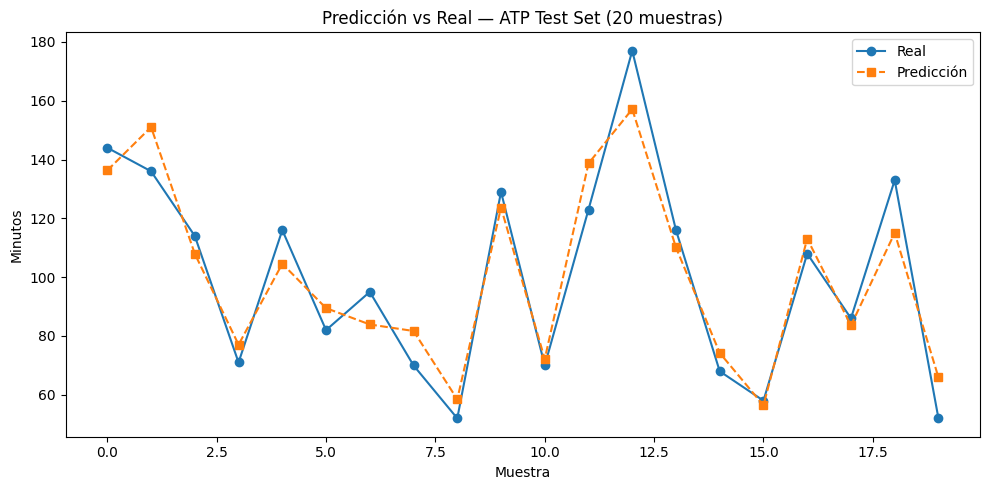

In [13]:
rng2 = np.random.default_rng(7)
idx_sample = rng2.choice(len(trues_min), 20, replace=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trues_min[idx_sample],  'o-', label='Real')
ax.plot(preds_min[idx_sample],  's--', label='Predicción')
ax.set_xlabel('Muestra'); ax.set_ylabel('Minutos')
ax.set_title('Predicción vs Real — ATP Test Set (20 muestras)')
ax.legend(); plt.tight_layout(); plt.show()


### 6.4 Predicción manual

Ingresa los datos de un partido para predecir su duración usando las mismas features del entrenamiento.

In [14]:
partido = {
    'surface': 'Clay',
    'best_of': 3,
    'draw_size': 32,
    'tourney_level': 'A',
    'round': 'R32',
    'winner_rank': 5,
    'loser_rank': 122,
    'winner_rank_points': 5200,
    'loser_rank_points': 480,
    'winner_age': 27.4,
    'loser_age': 23.1,
    'winner_ht': 188,
    'loser_ht': 182,
    'w_ace': 8,
    'l_ace': 3,
    'w_df': 2,
    'l_df': 3,
    'w_svpt': 78,
    'l_svpt': 73,
    'w_1stIn': 48,
    'l_1stIn': 45,
    'w_1stWon': 36,
    'l_1stWon': 31,
    'w_2ndWon': 14,
    'l_2ndWon': 11,
    'w_SvGms': 12,
    'l_SvGms': 11,
    'w_bpSaved': 4,
    'l_bpSaved': 3,
    'w_bpFaced': 6,
    'l_bpFaced': 7,
}

# Alinear exactamente al espacio de features usado en entrenamiento
x_input = pd.DataFrame([partido])
x_input = pd.get_dummies(x_input, columns=['surface', 'tourney_level', 'round'], dtype=np.float32)
x_input = x_input.reindex(columns=FEATURES, fill_value=0.0)

x_raw = x_input.values.astype(np.float32)
x_norm = (x_raw - mean_X) / std_X
x_in   = torch.tensor(x_norm, dtype=torch.float32).to(DEVICE)

best_model.eval()
with torch.no_grad():
    pred_norm = best_model(x_in).item()
pred_min = pred_norm * std_y + mean_y
print(f"Predicción de duración: {pred_min:.0f} minutos (~{pred_min/60:.1f} horas)")


Predicción de duración: 100 minutos (~1.7 horas)
